
# DS 352 • Part 2 (Exploratory, Slim Version)
**Tools:** Python 3.x, Pandas, NumPy, Matplotlib (no seaborn)

**What this notebook does (simplified):**
- Loads the the dataset
- **Summary stats** → then **identify and handle outliers** (IQR winsorization)
- **Missingness of data** (bar chart)
- **Binarization** of *low/high* values for a small set of nutrients
- **Category summary** by **median** nutrient values
- **Scatterplot matrix** for just: calories, carbs, protein, fat, sodium, fiber

**Removed:** histograms, boxplots, correlation heatmap, and any file saving.


In [2]:

# ================================
# Setup
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

DATA_PATH = "usda_branded_with_nutrition_per_serving (1).csv"  # adjust if needed
print("Ready. Will load from:", DATA_PATH)


Ready. Will load from: usda_branded_with_nutrition_per_serving (1).csv


## 1) Load dataset

In [3]:

df = pd.read_csv(DATA_PATH, low_memory=False)
print("Shape:", df.shape)
df.head(10)


Shape: (1048575, 15)


,company_brand,product,branded_food_category,serving_size,serving_size_unit,calories_per_serving,protein_g_per_serving,carbs_g_per_serving,fat_g_per_serving,fiber_g_per_serving,sodium_mg_per_serving,cholesterol_mg_per_serving,satfat_g_per_serving,iron_mg_per_serving,potassium_mg_per_serving
0,Richardson Oilseed Products (US) Limited,WESSON Vegetable Oil 1 GAL,Oils Edible,15.0,ml,130.05,0.0000,0.0000,13.9995,0.000,0.00,0.00,1.9995,0.0000,0.00
1,CAMPBELL SOUP COMPANY,SWANSON BROTH BEEF,Herbs/Spices/Extracts,240.0,ml,9.60,1.9920,1.0080,0.0000,0.000,830.40,0.00,0.0000,0.0000,0.00
2,CAMPBELL SOUP COMPANY,CAMPBELL'S SLOW KETTLE SOUP CLAM CHOWDER,Prepared Soups,440.0,g,360.80,10.7800,26.9280,23.3640,1.760,1597.20,26.40,4.4880,1.0560,286.00
3,CAMPBELL SOUP COMPANY,CAMPBELL'S SLOW KETTLE SOUP CHEESE BROCCOLI,Prepared Soups,440.0,g,360.80,5.3680,23.3640,26.9280,1.760,1416.80,44.00,10.7800,0.7040,286.00
4,CAMPBELL SOUP COMPANY,SWANSON BROTH CHICKEN,Herbs/Spices/Extracts,240.0,ml,9.60,1.9920,1.0080,0.0000,0.000,36.00,0.00,0.0000,0.0000,28.80
5,CAMPBELL SOUP COMPANY,CAMPBELL'S SOUP BEAN AND HAM,Prepared Soups,412.0,g,251.32,15.1204,43.7132,2.5132,9.888,1260.72,16.48,0.0000,3.3784,638.60
6,CAMPBELL SOUP COMPANY,SWANSON BROTH BEEF,Herbs/Spices/Extracts,411.0,g,16.44,3.4935,1.7673,0.0000,0.000,1450.83,0.00,0.0000,0.3699,53.43
7,CAMPBELL SOUP COMPANY,PREGO SAUCES TOMATO BASIL,Sauces/Spreads/Dips/Condiments,120.0,ml,69.60,2.0040,6.9960,3.9960,3.000,429.60,0.00,0.5040,0.3600,210.00
8,CAMPBELL SOUP COMPANY,CAMPBELL'S SOUP TOMATO,Prepared Soups,120.0,ml,90.00,2.0040,18.0000,1.5000,0.960,410.40,0.00,0.0000,0.3960,620.40
9,CAMPBELL SOUP COMPANY,CAMPBELL'S PASTA SPAGHETTIOS W FRANKS,Dough Based Products / Meals,443.0,g,385.41,15.8151,50.9893,12.3154,5.316,1054.34,44.30,3.4997,2.7909,651.21


## 2) Select core nutrient columns & coerce numeric

In [4]:

CORE = [
    "calories_per_serving",
    "carbs_g_per_serving",
    "protein_g_per_serving",
    "fat_g_per_serving",
    "sodium_mg_per_serving",
    "fiber_g_per_serving",
]

present = [c for c in CORE if c in df.columns]
missing_cols = [c for c in CORE if c not in df.columns]
if missing_cols:
    print("Missing expected columns (will skip):", missing_cols)

for c in present:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Columns used:", present)
df[present].head(5)


Columns used: ['calories_per_serving', 'carbs_g_per_serving', 'protein_g_per_serving', 'fat_g_per_serving', 'sodium_mg_per_serving', 'fiber_g_per_serving']


,calories_per_serving,carbs_g_per_serving,protein_g_per_serving,fat_g_per_serving,sodium_mg_per_serving,fiber_g_per_serving
0,130.05,0.000,0.000,13.9995,0.0,0.00
1,9.60,1.008,1.992,0.0000,830.4,0.00
2,360.80,26.928,10.780,23.3640,1597.2,1.76
3,360.80,23.364,5.368,26.9280,1416.8,1.76
4,9.60,1.008,1.992,0.0000,36.0,0.00


## 3) Summary stats (before outlier handling)

In [5]:

summary_before = df[present].describe(percentiles=[.05,.25,.5,.75,.95]).T.round(3)
summary_before


,count,mean,std,min,5%,25%,50%,75%,95%,max
calories_per_serving,1026383.0,136.038,238.216,0.0,4.6,60.0,120.000,170.100,309.550,18570.420
carbs_g_per_serving,1037363.0,18.168,40.539,0.0,0.0,4.0,15.997,25.001,43.003,7325.007
protein_g_per_serving,1044521.0,4.486,13.156,0.0,0.0,0.0,2.000,6.000,15.999,900.018
fat_g_per_serving,1022425.0,5.489,9.188,0.0,0.0,0.0,3.000,8.999,17.000,900.000
sodium_mg_per_serving,1030817.0,402.362,9355.735,0.0,0.0,24.8,119.850,280.000,709.710,1460001.360
fiber_g_per_serving,854175.0,1.530,3.191,0.0,0.0,0.0,1.000,2.010,5.002,330.120


## 4) Identify & handle outliers (IQR winsorization)

In [6]:

def winsorize_iqr(series, k=1.5):
    s = series.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - k*iqr
    upper = q3 + k*iqr
    return series.clip(lower, upper)

print("Applying IQR winsorization per nutrient (k=1.5).")
df_w = df.copy()
for c in present:
    df_w[c] = winsorize_iqr(df[c], k=1.5)

summary_after = df_w[present].describe(percentiles=[.05,.25,.5,.75,.95]).T.round(3)
print("=== Summary AFTER winsorization ===")
summary_after


Applying IQR winsorization per nutrient (k=1.5).
=== Summary AFTER winsorization ===


,count,mean,std,min,5%,25%,50%,75%,95%,max
calories_per_serving,1026383.0,125.154,84.849,0.0,4.6,60.0,120.000,170.100,309.550,335.250
carbs_g_per_serving,1037363.0,16.723,14.000,0.0,0.0,4.0,15.997,25.001,43.003,56.503
protein_g_per_serving,1044521.0,3.848,4.387,0.0,0.0,0.0,2.000,6.000,15.001,15.001
fat_g_per_serving,1022425.0,5.206,5.832,0.0,0.0,0.0,3.000,8.999,17.000,22.497
sodium_mg_per_serving,1030817.0,185.355,197.662,0.0,0.0,24.8,119.850,280.000,662.800,662.800
fiber_g_per_serving,854175.0,1.350,1.456,0.0,0.0,0.0,1.000,2.010,5.002,5.025


## 5) Missingness of data (bar chart)

fiber_g_per_serving      0.185
fat_g_per_serving        0.025
calories_per_serving     0.021
sodium_mg_per_serving    0.017
carbs_g_per_serving      0.011
protein_g_per_serving    0.004
dtype: float64


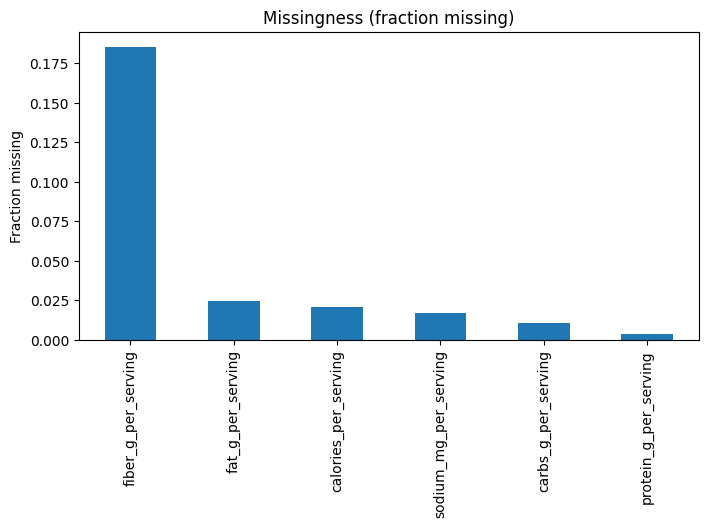

In [7]:

miss = df_w[present].isna().mean().sort_values(ascending=False)
print(miss.round(3))
ax = miss.plot(kind="bar", figsize=(8,4))
plt.title("Missingness (fraction missing)")
plt.ylabel("Fraction missing")
plt.show()


## 6) Binarization of low/high values (median-like via qcut; fallback median split)

In [8]:

bin_cols = {}
for c in present:
    s = df_w[c]
    try:
        labels = ["low","high"]
        df_w[c+"_bin"] = pd.qcut(s, q=2, labels=labels, duplicates="drop")
        if df_w[c+"_bin"].nunique(dropna=True) < 2:
            raise ValueError("Insufficient unique values for qcut; fallback to median split.")
    except Exception as e:
        med = s.median()
        df_w[c+"_bin"] = np.where(s <= med, "low", "high")
    bin_cols[c+"_bin"] = df_w[c+"_bin"].value_counts(dropna=False)

print("Bin counts per nutrient (low/high):")
for k, v in bin_cols.items():
    print(f"\n{k}\n{v}")


Bin counts per nutrient (low/high):

calories_per_serving_bin
calories_per_serving_bin
low     534282
high    492101
NaN      22192
Name: count, dtype: int64

carbs_g_per_serving_bin
carbs_g_per_serving_bin
low     519348
high    518015
NaN      11212
Name: count, dtype: int64

protein_g_per_serving_bin
protein_g_per_serving_bin
low     523178
high    521343
NaN       4054
Name: count, dtype: int64

fat_g_per_serving_bin
fat_g_per_serving_bin
low     514982
high    507443
NaN      26150
Name: count, dtype: int64

sodium_mg_per_serving_bin
sodium_mg_per_serving_bin
low     515524
high    515293
NaN      17758
Name: count, dtype: int64

fiber_g_per_serving_bin
fiber_g_per_serving_bin
low     438452
high    415723
NaN     194400
Name: count, dtype: int64


## 7) Category summary by median nutrient values

In [9]:

cat_col = None
for cand in ["branded_food_category", "category_family", "category", "food_category"]:
    if cand in df_w.columns:
        cat_col = cand
        break

if cat_col is None:
    print("No category column found among: branded_food_category, category_family, category, food_category")
else:
    med_cols = {f"{c}_med": (c, "median") for c in present}
    cat_summary = df_w.groupby(cat_col).agg(n=(present[0], "count"), **med_cols).sort_values("n", ascending=False)
    print(f"Category column used: {cat_col}")
    cat_summary.head(20)


Category column used: branded_food_category


## 8) Scatterplot matrix (calories, carbs, protein, fat, sodium, fiber)

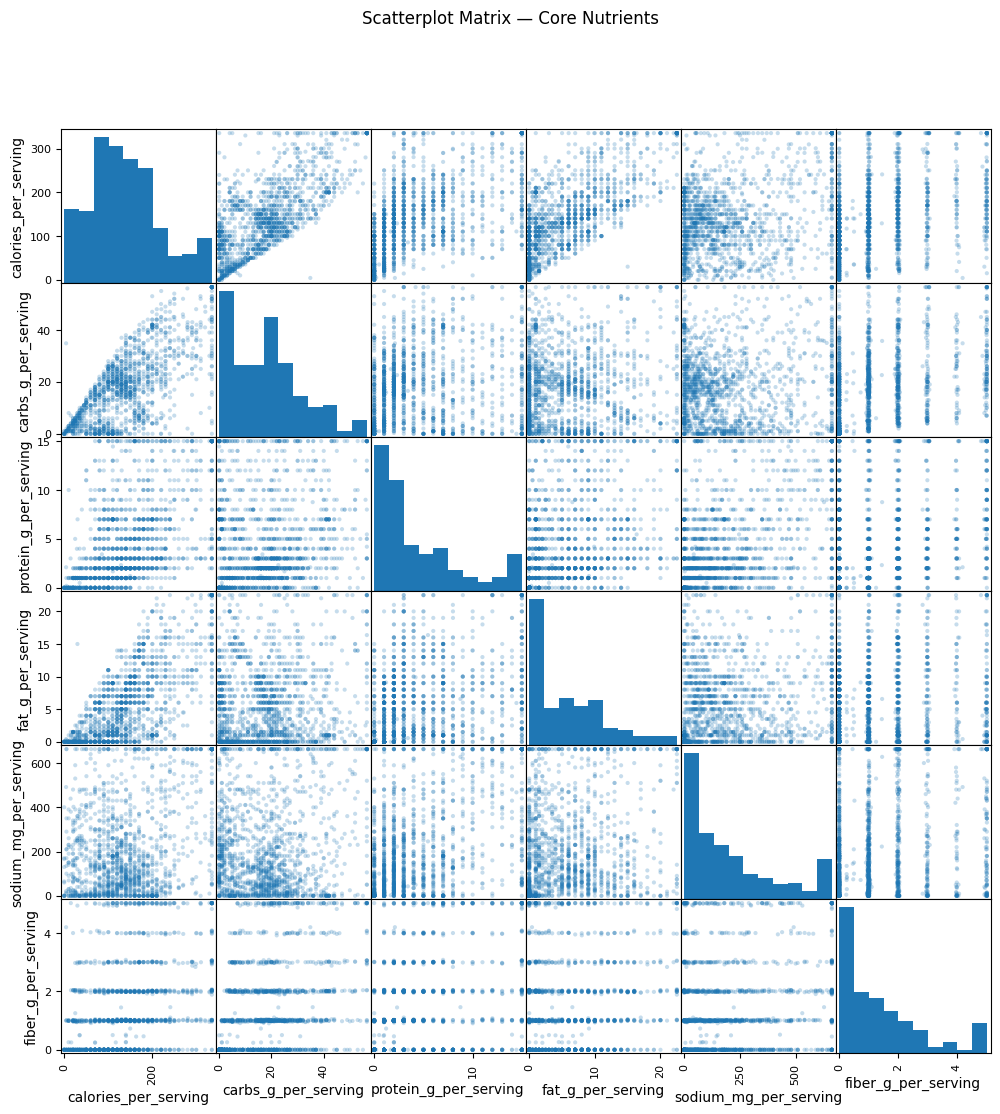

In [10]:

use_for_matrix = [c for c in ["calories_per_serving","carbs_g_per_serving","protein_g_per_serving","fat_g_per_serving","sodium_mg_per_serving","fiber_g_per_serving"] if c in df_w.columns]
df_for_matrix = df_w[use_for_matrix].dropna()

MAX_SMPL = 1500
if len(df_for_matrix) > MAX_SMPL:
    df_for_matrix = df_for_matrix.sample(MAX_SMPL, random_state=42)

axarr = scatter_matrix(df_for_matrix, figsize=(12, 12), diagonal='hist', alpha=0.25)
plt.suptitle("Scatterplot Matrix — Core Nutrients")
plt.show()


## 9) Notes

In [11]:

print("* Outliers handled via IQR winsorization (k=1.5).")
print("* Binarization uses median-like split per feature → 'low'/'high'.")
print("* Category medians: quick way to compare typical nutrient levels across groups.")
print("* Scatterplot matrix limited to core nutrients for clarity.")
print("* No files are saved in this slim version; everything is printed or shown inline.")


* Outliers handled via IQR winsorization (k=1.5).
* Binarization uses median-like split per feature → 'low'/'high'.
* Category medians: quick way to compare typical nutrient levels across groups.
* Scatterplot matrix limited to core nutrients for clarity.
* No files are saved in this slim version; everything is printed or shown inline.
